In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("OPENAI_API_KEY") is None:
    raise ValueError("Please set OPENAI_API_KEY environment variable")
else:
    llm = ChatOpenAI(model="gpt-5-nano")
    output = llm.invoke("I want to know the meaning of water").content
    print(output)

Here are the main ways people use and understand "water":

- Scientific definition
  - Water is a chemical compound with the formula H2O: two hydrogen atoms bonded to one oxygen.
  - It is a polar molecule, forms hydrogen bonds, and exists as a liquid, solid (ice), or gas (steam) depending on temperature and pressure.
  - It’s an excellent solvent and is essential for all known forms of life.

- Physical properties and role on Earth
  - Covers about 71% of Earth’s surface, mainly oceans.
  - Water has high heat capacity and surface tension, and ice is less dense than liquid water, causing it to float.
  - The water cycle moves water through evaporation, condensation, precipitation, and collection.

- Biological and practical importance
  - All living organisms need water to survive.
  - Freshwater is limited; most of Earth's freshwater is locked in ice or inaccessible underground, making water conservation important.

- Symbolic and cultural meanings
  - Often represents life, purity, 

In [3]:
# Step 1 - Define the schema
from typing import TypedDict, List

class GraphState(TypedDict):
    name: str
    message: str

In [4]:
# Step 2 - Create the Node functions
def welcome(state: GraphState) -> GraphState:
    current_name = state["name"]
    current_message = state["message"]
    response = llm.invoke(f"My name is {current_name}. {current_message}").content
    state["message"] = f"Your message is {current_message} , My message is {response}"
    return state

In [5]:
# Step 3 Create stategraph
from langgraph.graph import StateGraph, START, END

graph = StateGraph(GraphState)
graph.add_node("welcome", welcome)
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)


In [6]:
first_graph = graph.compile()

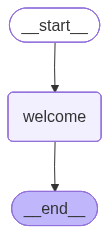

In [7]:
from IPython.display import Image, display
Image(first_graph.get_graph().draw_mermaid_png())

In [8]:
first_graph.invoke({"name": "Optimus Prime", "message": "Hello"})

{'name': 'Optimus Prime',
 'message': 'Your message is Hello , My message is Hello, Optimus Prime! Pleasure to meet you. How can I assist you today, Commander?'}

### Pydantic Schema

In [9]:
from pydantic import BaseModel, Field

class PydanticState(BaseModel):
    topic: str = Field(description="The topic of the conversation")
    post: str = Field(description="Linkedin post content")
    curated_post: str = Field(description="Curated post content")

In [10]:
demo_object = PydanticState(topic="Python", post="Python is awesome", curated_post="Python is the best language")
print(demo_object)

topic='Python' post='Python is awesome' curated_post='Python is the best language'


In [11]:
def create_post(state: PydanticState) -> PydanticState:
    # convert pydantic model to a dictionary
    state_dict = state.model_dump()

    # extract the topic
    topic = state_dict["topic"]

    # pass the topic to llm.invoke
    response = llm.invoke(f"Write a linkedin post for the topic {topic}").content

    # set the post
    state_dict["post"] = response
    return PydanticState(**state_dict)


In [12]:
def curate_post(state: PydanticState) -> PydanticState:

    # convert pydantic model to a dictionary
    state_dict = state.model_dump()

    post = state_dict["post"]
    curated_post = llm.invoke(f"Curate the post {post}").content
    state_dict["curated_post"] = curated_post
    return PydanticState(**state_dict)

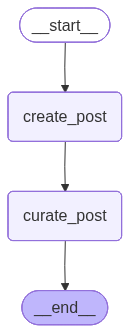

In [13]:
# create the graph
graph = StateGraph(PydanticState)
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)
pydantic_graph = graph.compile()

Image(pydantic_graph.get_graph().draw_mermaid_png())

In [14]:
pydantic_graph.invoke(
    {"topic": "Python Programming Language", "post": "", "curated_post": ""}
)

{'topic': 'Python Programming Language',
 'post': 'Python remains the Swiss Army knife of programming. Clean, readable syntax plus a vast ecosystem lets you go from idea to production faster than almost any other language.\n\nWhy Python stays relevant in 2026:\n- Readability and developer happiness that help teams onboard and scale\n- A rich library ecosystem across domains: web dev (Django, FastAPI), data science (Pandas, NumPy), ML/AI (scikit-learn, PyTorch, TensorFlow), automation, scripting\n- Cross-platform practicality and strong tooling: virtual environments, pip, Poetry, robust testing\n- A passionate, collaborative community with generous learning resources\n\nWhether you’re building web apps, analyzing data, or automating repetitive tasks, Python makes it easier to prototype and iterate. If you’re starting out, focus on fundamentals, then experiment with a couple of domains you care about. Build small projects to learn how to glue components together and how to deploy somethi

In [15]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

llm.invoke([HumanMessage(content="Hello")]).content

'Hi there! How can I help you today? I can answer questions, explain concepts, help with writing or code, brainstorm ideas, translate, plan things, and more.'

# Tools & Binding